In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

module_path = os.path.abspath(os.path.join("../.."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [23]:
from machines.predictions import RF_Prediction
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
file_csv = "../../../data/obregon_1516_1617/original/o_57_o_phenotypic.csv"
# print(os.getcwd())
df = pd.read_csv(file_csv)

columns_no_ndvi = []
for col in df.columns:
    if "ndvi" not in col.lower():
        columns_no_ndvi.append(col)

print(columns_no_ndvi)
new_csv_file = "test_no_ndvi.csv"
df.to_csv(new_csv_file, index=False)

['TGW', 'HI', 'BM', 'CT_UAV_1', 'CT_UAV_2', 'CT_UAV_3', 'CT_UAV_4', 'YLD']


In [26]:
preprocessing = Preprocess(file_name=new_csv_file, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PASS,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()
x_train, y_train = preprocessing.get_train()

In [27]:
machine = RF_Prediction(n_estimators=1000)
machine.training(x_train=x_train, y_train=y_train)

In [28]:
x_test, y_test = preprocessing.get_test()
y_predicted = machine.prediction(x_test=x_test)

In [29]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print(
    "Root mean squared error -> {}".format(
        metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)
    )
)
print("R2 -> {}".format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print(
    "MAPE -> {}".format(
        metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)
    )
)
metric.get_all_from_predict()

Root mean squared error -> 47.055007975465145
R2 -> 0.7701224309361724
MAPE -> 0.06177629850595305


{'d2_absolute_error_score': 0.5140038756857079,
 'd2_pinball_score': 0.5140038756857079,
 'd2_tweedie_score': 0.7701224309361724,
 'explained_variance_score': 0.7751364762187225,
 'max_error': 231.10858968675143,
 'mean_absolute_error': 33.911597519722356,
 'mean_absolute_percentage_error': 0.06177629850595305,
 'mean_gamma_deviance': 0.007635566221348263,
 'mean_poisson_deviance': 3.9637640310092976,
 'mean_squared_error': 2214.1737755710883,
 'mean_squared_log_error': 0.008186846478205263,
 'median_absolute_error': 25.343228706528294,
 'r2_score': 0.7701224309361724,
 'root_mean_squared_error': 47.055007975465145,
 'root_mean_squared_log_error': 0.09048119405824209}

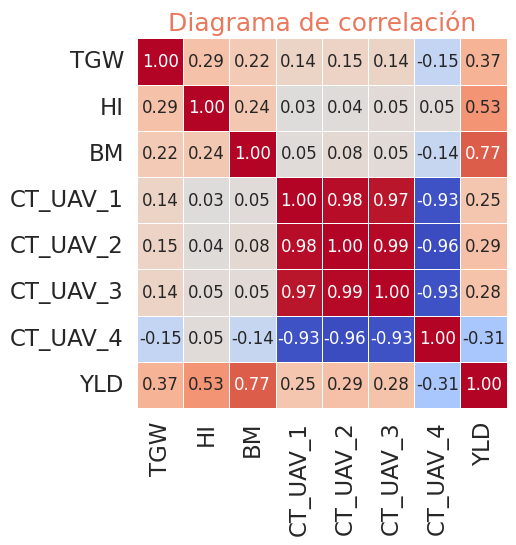

In [34]:
mean = df.mean()
df.fillna(mean, inplace=True)
corr = np.corrcoef(df[columns_no_ndvi].values.T)
# print(corr)
sns.set(font_scale=1.5)
sns.heatmap(
    corr,
    xticklabels=columns_no_ndvi,
    yticklabels=columns_no_ndvi,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    cbar=False,
    square=True,
    annot_kws={"size": 12},
    linewidth=0.5,
)
plt.title("Diagrama de correlación", color="#E9785D")
plt.show()

In [60]:
threshold = 0.95
# corr_matrix = np.corrcoef(df[columns_no_ndvi].T)
upper_tri = np.triu(np.abs(corr), k=1)
valid_cols = np.array(upper_tri.max(axis=0) < threshold)
valid_cols = valid_cols.tolist()

valid_cols

columns_no_ndvi_correlation = np.array(columns_no_ndvi)[valid_cols].tolist()

print(columns_no_ndvi_correlation)

file_csv_no_ndvi_correlation = "test_no_ndvi_correlation.csv"
df[columns_no_ndvi_correlation].to_csv(file_csv_no_ndvi_correlation, index=False)

['TGW', 'HI', 'BM', 'CT_UAV_1', 'YLD']


Test only no correlation variables

In [65]:
preprocessing = Preprocess(
    file_name=file_csv_no_ndvi_correlation, type_file=TypeFileEnum.CSV
)
preprocessing.read_file(
    transform=TransformEnum.PASS,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()
x_train, y_train = preprocessing.get_train()

machine = RF_Prediction(n_estimators=1000)
machine.training(x_train=x_train, y_train=y_train)

x_test, y_test = preprocessing.get_test()
y_predicted = machine.prediction(x_test=x_test)

metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print(
    "Root mean squared error -> {}".format(
        metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)
    )
)
print("R2 -> {}".format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print(
    "MAPE -> {}".format(
        metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)
    )
)
metric.get_all_from_predict()

Root mean squared error -> 35.01335255625817
R2 -> 0.8727223093690163
MAPE -> 0.03679438352070334


{'d2_absolute_error_score': 0.6938389159611087,
 'd2_pinball_score': 0.6938389159611087,
 'd2_tweedie_score': 0.8727223093690163,
 'explained_variance_score': 0.8728740063015217,
 'max_error': 200.1846511,
 'mean_absolute_error': 21.363156903314113,
 'mean_absolute_percentage_error': 0.03679438352070334,
 'mean_gamma_deviance': 0.003525584381564698,
 'mean_poisson_deviance': 2.0302832235378405,
 'mean_squared_error': 1225.9348572288307,
 'mean_squared_log_error': 0.003668211190644894,
 'median_absolute_error': 11.369634049999888,
 'r2_score': 0.8727223093690163,
 'root_mean_squared_error': 35.01335255625817,
 'root_mean_squared_log_error': 0.06056575922619062}

In [85]:
def get_machine_metric(machine, file_csv):
    preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
    preprocessing.read_file(
        transform=TransformEnum.PASS,
        standard_scale=StandardScaleEnum.BASIC,
    )
    preprocessing.build_train_and_test()
    x_train, y_train = preprocessing.get_train()

    # machine = RF_Prediction(n_estimators=1000)
    machine.training(x_train=x_train, y_train=y_train)

    x_test, y_test = preprocessing.get_test()
    y_predicted = machine.prediction(x_test=x_test)

    metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
    metric.calculate_metric_prediction()
    return (
        metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR),
        metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR),
        metric.get_metric(metric=MetricEnum.R2_SCORE),
    )

In [87]:
import itertools

columns_to_iterate = columns_no_ndvi_correlation[:-1]
column_y = columns_no_ndvi_correlation[-1]

print(columns_to_iterate, column_y)

columns_selection = [
    x for x in itertools.product([True, False], repeat=len(columns_to_iterate))
][:-1]
mape = 1
best = []
metrics = []
for columns in columns_selection:
    selected = np.array(columns_to_iterate)[np.array(columns)].tolist()
    selected.append(column_y)
    file_csv = "test_selection_characteristic.csv"
    df[selected].to_csv(file_csv, index=False)
    new_mape, rsme, r2 = get_machine_metric(
        machine=RF_Prediction(n_estimators=1000), file_csv=file_csv
    )
    metrics.append({"selected": selected, "mape": new_mape, "rsme": rsme, "r2": r2})
    if new_mape < mape:
        mape = new_mape
        best = selected

print(mape, best, metrics)

['TGW', 'HI', 'BM', 'CT_UAV_1'] YLD
0.03522998005258112 ['HI', 'BM', 'CT_UAV_1', 'YLD'] [{'selected': ['TGW', 'HI', 'BM', 'CT_UAV_1', 'YLD'], 'mape': 0.036794383520703335, 'rsme': 35.01335255625817, 'r2': 0.8727223093690163}, {'selected': ['TGW', 'HI', 'BM', 'YLD'], 'mape': 0.04011506152786484, 'rsme': 37.550186656983534, 'r2': 0.8536107811103604}, {'selected': ['TGW', 'HI', 'CT_UAV_1', 'YLD'], 'mape': 0.10495590910143283, 'rsme': 75.97913673824078, 'r2': 0.40065953167821033}, {'selected': ['TGW', 'HI', 'YLD'], 'mape': 0.10762364782625504, 'rsme': 77.60287741854846, 'r2': 0.3747689431061575}, {'selected': ['TGW', 'BM', 'CT_UAV_1', 'YLD'], 'mape': 0.06307428137205011, 'rsme': 48.5876271507972, 'r2': 0.7549039718433734}, {'selected': ['TGW', 'BM', 'YLD'], 'mape': 0.06665257581961441, 'rsme': 51.422635872426184, 'r2': 0.725467628363002}, {'selected': ['TGW', 'CT_UAV_1', 'YLD'], 'mape': 0.13450392484398282, 'rsme': 96.5391557656738, 'r2': 0.03240885254169035}, {'selected': ['TGW', 'YLD'], 